## Why Chernoff Bounds and MGFs?

`method_v2` turns the GP's prediction of an execution time (mean $\mu$, standard deviation $\sigma$) into a latency
bound for a service chain via Moment Generating Functions (MGFs) and Chernoff bounds. This notebook asks why that
detour is needed, which alternatives exist, and when it is the right choice.

We want a latency $d$ with $P(W > d) \le \varepsilon$ that includes the **queue**, **composes** over a chain, is a
**guarantee** (not an estimate that is below the truth half of the time), and is **cheap** enough for the optimizer.
The short answer, checked step by step below:

1. **Quantiles don't add:** the p95 of a sum is not a function of the parts' p95s (Section 2).
2. **Queues have no closed-form quantile**, but their tail is governed exactly by the MGF (Section 3).
3. **MGFs compose by addition** and give a closed form that is far cheaper than simulation (Sections 2, 6).
4. **The SNC bound of `method_v2` is not the best MGF bound:** a martingale bound from the same inputs is much
   tighter (Sections 4, 5).
5. **The MGF must be right:** a Gaussian MGF under-covers when execution times have rare slow outliers (Section 7).

| symbol | meaning | unit |
|---|---|---|
| $X$ | execution time of one item at a service (the GP's target), mean $\mu$, std $\sigma$ | s |
| $T$, $\lambda$ | gap between two arrivals; arrival rate $1/\mathbb{E}[T]$ | s; items/s |
| $\rho = \lambda\mu$ | utilization (share of time the server is busy) | – |
| $Q$, $W = Q + X$ | waiting time; latency (sojourn time) of an item at one service | s |
| $\varepsilon$ | violation probability (p95 ↔ $\varepsilon = 0.05$) | – |
| $d(\varepsilon)$ | bound or estimate produced by a method; compared with the true $(1-\varepsilon)$-quantile from a long simulation | s |
| $\theta$ | free parameter of the MGF | 1/s |
| $K$ | number of services on a path | – |

**Tightness** is $d(\varepsilon)$ ÷ the true quantile; below 1 means the method **under-covers**. The service
parameters are those of s1 in `why_poisson_is_loose`. Execution times are known exactly (no GP), which isolates the
step from execution-time distribution to latency bound.

In [2]:
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from scipy.stats import binom, norm

plt.style.use("default")
plt.rcParams.update({"font.size": 12})
# Monte Carlo has no bound for the smallest eps (too few samples); nan-aware reductions over those columns are expected
warnings.filterwarnings("ignore", message="All-NaN slice encountered")

mu, sigma = 0.080, 0.006       # mean and std of the execution time of s1 (s), as in why_poisson_is_loose
arrival_rate = 8.0             # lambda (items/s); utilization rho = lambda * mu
jitter = 0.1                   # relative half-width of the uniform jitter on periodic gaps
epsilon = 0.05                 # violation probability (p95)
epsilons = np.array([1e-1, 5e-2, 1e-2, 3e-3, 1e-3, 3e-4, 1e-4])   # sweep of violation probabilities
delta_mc = 0.05                # Monte Carlo: allowed probability that the order-statistic bound is below the truth
n_mc = 2000                    # Monte Carlo: independent latency samples per configuration

theta_grid = np.logspace(-1, 5, 4000)   # MGF parameter theta (1/s), same grid as method_v2
processes = ["poisson", "periodic"]


def ms(seconds):
    return f"{seconds * 1000:.0f} ms"


# ---- MGFs on theta_grid ------------------------------------------------------------------------------------------
def log_mgf_gauss(m, s):
    # ln M_X(theta) of a Gaussian execution time
    return theta_grid * m + 0.5 * theta_grid ** 2 * s ** 2


def log_gap_mgf(process, rate):
    # ln E[exp(-theta T)] of one inter-arrival gap T
    if process == "poisson":
        return np.log(rate / (rate + theta_grid))
    shortest, width = (1 - jitter) / rate, 2 * jitter / rate
    return -theta_grid * shortest + np.log(-np.expm1(-theta_grid * width)) - np.log(theta_grid * width)


# ---- the two MGF-based latency bounds (Section 4) ----------------------------------------------------------------
def snc_bound(log_mx, log_gap, eps):
    # method_v2: d = min over theta with rho(theta) < 1 of [ln M_X - ln(1 - rho(theta)) - ln eps] / theta
    log_rho = log_mx + log_gap
    stable = log_rho < 0
    values = np.full_like(log_mx, np.inf)
    values[stable] = (log_mx[stable] - np.log1p(-np.exp(log_rho[stable])) - np.log(eps)) / theta_grid[stable]
    return values.min()


def martingale_bound(log_mx, log_gap, eps):
    # Kingman: d = min over theta with rho(theta) <= 1 of [ln M_X - ln eps] / theta
    allowed = log_mx + log_gap <= 0
    values = np.full_like(log_mx, np.inf)
    values[allowed] = (log_mx[allowed] - np.log(eps)) / theta_grid[allowed]
    return values.min()


# ---- ground truth: a chain of FIFO servers, vectorized over independent replications ---------------------------
def sample_gaps(process, shape, rng, rate):
    if process == "poisson":
        return rng.exponential(1.0 / rate, shape)
    return (1.0 / rate) * (1 + rng.uniform(-jitter, jitter, shape))


def gauss_sampler(m, s):
    return lambda rng, n: np.maximum(rng.normal(m, s, n), 0.0)


def simulate(process, rate, samplers, n_chains, n_steps, rng, warmup):
    # Runs n_chains independent copies of a chain of FIFO servers (one sampler of execution times per server) for
    # n_steps items each. Returns end-to-end latencies and the waits at the first server, one row per copy,
    # without the first `warmup` items of every copy (the queues start empty).
    arrival = np.zeros(n_chains)
    last_leave = np.zeros((len(samplers), n_chains))
    latency = np.empty((n_chains, n_steps - warmup))
    wait = np.empty((n_chains, n_steps - warmup))
    for step in range(n_steps):
        arrival = arrival + sample_gaps(process, n_chains, rng, rate)
        entering = arrival
        for k, sampler in enumerate(samplers):
            start = np.maximum(entering, last_leave[k])
            if k == 0 and step >= warmup:
                wait[:, step - warmup] = start - entering
            last_leave[k] = start + sampler(rng, n_chains)
            entering = last_leave[k]
        if step >= warmup:
            latency[:, step - warmup] = entering - arrival
    return latency, wait


def plot_ratios(ax, results, styles, title):
    # one line per method: d(eps) / true quantile; Monte Carlo (2-D) as median with a min-max band over repetitions
    truth = results["truth"]
    for name, (color, marker) in styles.items():
        values = results.get(name)
        if values is None:
            continue
        if values.ndim == 2:
            ratio = values / truth
            ax.fill_between(epsilons, np.nanmin(ratio, axis=0), np.nanmax(ratio, axis=0), color=color, alpha=0.2)
            values = np.nanmedian(values, axis=0)
        ax.semilogx(epsilons, values / truth, marker=marker, color=color, linewidth=1.5, label=name)
    ax.axhline(1, color="black", linewidth=1, label="true quantile")
    ax.invert_xaxis()
    ax.set_xlabel("violation probability ε (smaller = stricter)")
    ax.set_ylabel("d(ε) ÷ true quantile")
    ax.set_title(title, fontsize=12)
    ax.grid(True, which="both", linestyle=":", alpha=0.5)


display(Markdown(f"Service: $\\mu$ = {ms(mu)}, $\\sigma$ = {ms(sigma)}; $\\lambda$ = {arrival_rate:g}/s, "
                 f"so $\\rho = \\lambda\\mu$ = {arrival_rate * mu:.2f}. Target $\\varepsilon$ = {epsilon:g}."))

Service: $\mu$ = 80 ms, $\sigma$ = 6 ms; $\lambda$ = 8/s, so $\rho = \lambda\mu$ = 0.64. Target $\varepsilon$ = 0.05.

## 0. The Moment Generating Function $M_X(\theta)$

**Definition.** $M_X(\theta) = \mathbb{E}[e^{\theta X}]$: the average of $e^{\theta X}$ over many items, one number
per $\theta$ ($\theta$ in 1/s, so $\theta X$ has no unit). For a Gaussian $X$, as the GP delivers, it is
$\exp(\theta\mu + \theta^2\sigma^2/2)$.

**Why "moment generating".** Averaging the Taylor series of $e^{\theta X}$ gives
$M_X(\theta) = 1 + \theta\,\mathbb{E}[X] + \frac{\theta^2}{2}\mathbb{E}[X^2] + \dots$, so the MGF holds *all* moments
of $X$. The Gaussian is the case where $\ln M_X$ stops after the $\theta^2$ term: it sets skewness and tail weight to
zero (Section 7 tests what that costs).

**What $\theta$ does.** $e^{\theta X}$ weights large execution times exponentially more, so $\theta$ decides which
items dominate the average. Reweighting the density $f$ of $X$ by $e^{\theta x}$ gives the *tilted* distribution
$f_\theta(x) = e^{\theta x} f(x) / M_X(\theta)$. For a Gaussian it is the same Gaussian shifted up by
$\theta\sigma^2$: small $\theta$ sees the mean, large $\theta$ sees the upper tail.

**Three properties used throughout:**
1. *Sums become products:* for independent $X, Y$, $M_{X+Y} = M_X M_Y$, so log-MGFs add.
2. *Arrivals use a negative argument:* the bounds need $\mathbb{E}[e^{-\theta T}]$ of the gap $T$ (Poisson:
   $\lambda/(\lambda+\theta)$). With property 1, $\rho(\theta) = M_X(\theta)\,\mathbb{E}[e^{-\theta T}] = \mathbb{E}[e^{\theta(X-T)}]$
   is the MGF of "work brought by one item minus the time until the next one arrives".
3. *Existence:* $M_X(\theta)$ is finite only if the tail of $X$ decays at least exponentially. Log-normal and Pareto
   distributions have $M_X(\theta) = \infty$ for every $\theta > 0$, so no Chernoff bound exists for them.

| θ (1/s) | average of $e^{θX}$ over 10⁶ simulated items | closed form $\exp(θμ + θ^2σ^2/2)$ | mean of the tilted distribution, μ + θσ² |
|---|---|---|---|
| 100 | 3572 | 3569 | 84 ms |
| 400 | 1.409e+15 | 1.407e+15 | 94 ms |
| 1000 | 5.216e+41 | 3.638e+42 | 116 ms |

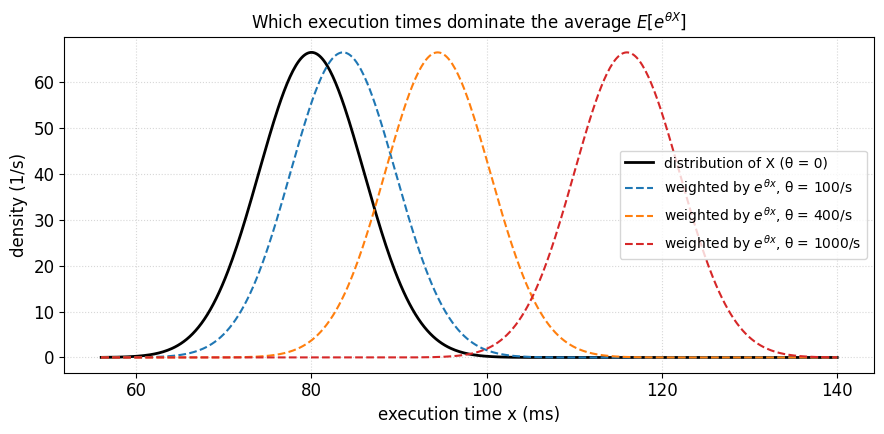

In [3]:
# M_X(theta) is an ordinary average: compare the closed form with the average of exp(theta X) over simulated items
x_samples = np.random.default_rng(0).normal(mu, sigma, 1_000_000)
thetas_shown = [100.0, 400.0, 1000.0]   # MGF parameters to illustrate (1/s)

rows = [f"| {t:g} | {np.mean(np.exp(t * x_samples)):.4g} | {np.exp(t * mu + 0.5 * t ** 2 * sigma ** 2):.4g} | {ms(mu + t * sigma ** 2)} |"
        for t in thetas_shown]
display(Markdown("| θ (1/s) | average of $e^{θX}$ over 10⁶ simulated items | closed form $\\exp(θμ + θ^2σ^2/2)$ | "
                 "mean of the tilted distribution, μ + θσ² |\n|---|---|---|---|\n" + "\n".join(rows)))

x_axis = np.linspace(mu - 4 * sigma, mu + thetas_shown[-1] * sigma ** 2 + 4 * sigma, 500)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(x_axis * 1000, norm.pdf(x_axis, mu, sigma), color="black", linewidth=2, label="distribution of X (θ = 0)")
for t, color in zip(thetas_shown, ["tab:blue", "tab:orange", "tab:red"]):
    # the tilted density of a Gaussian is again Gaussian, shifted by theta * sigma^2
    ax.plot(x_axis * 1000, norm.pdf(x_axis, mu + t * sigma ** 2, sigma), color=color, linewidth=1.5, linestyle="--",
            label=f"weighted by $e^{{θx}}$, θ = {t:g}/s")
ax.set_xlabel("execution time x (ms)")
ax.set_ylabel("density (1/s)")
ax.set_title("Which execution times dominate the average $E[e^{θX}]$", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

**What this shows.** The plot has execution time (ms) on the x-axis and density on the y-axis. The black curve is
the distribution of $X$; each dashed curve is the tilted distribution, i.e. the items that dominate
$\mathbb{E}[e^{\theta X}]$ for that $\theta$. As $\theta$ grows, the curve moves right by $\theta\sigma^2$, into the
region where $X$ has almost no mass.

The table shows the practical consequence. For small $\theta$ the sample average matches the closed form. At the
largest $\theta$ it falls short: the items that dominate the average lie so far out that even a million samples
barely contain any. An MGF estimated from measurements is therefore unreliable at large $\theta$, which is why the
bounds use a closed-form MGF.

## 1. From the MGF to a Tail Bound: Chernoff

The goal for a single execution time: find $d$ with $P(X > d) \le \varepsilon$. What can be guaranteed depends on
what is known about $X$:

- **Markov** (mean only, $X \ge 0$): $P(X \ge d) \le \mu/d$, so $d = \mu/\varepsilon$.
- **Cantelli** (mean and variance): $d = \mu + \sigma\sqrt{(1-\varepsilon)/\varepsilon}$. This is the best possible
  guarantee from $\mu$ and $\sigma$ alone.
- **Chernoff** (the MGF): apply Markov to $e^{\theta X}$ instead of $X$. Since $X \ge d$ exactly when
  $e^{\theta X} \ge e^{\theta d}$, we get $P(X \ge d) \le M_X(\theta)\,e^{-\theta d}$ for every $\theta > 0$. Setting
  the right side to $\varepsilon$ gives
  $$d = \underbrace{\frac{\ln M_X(\theta)}{\theta}}_{\text{pessimistic average of } X\text{, grows with } \theta} + \underbrace{\frac{\ln(1/\varepsilon)}{\theta}}_{\text{price of confidence, shrinks with } \theta}.$$
  The first term runs from $\mu$ (small $\theta$) towards the largest value of $X$ (large $\theta$); for a Gaussian it
  is $\mu + \theta\sigma^2/2$. The best $\theta$ balances the two terms (left plot). For a Gaussian this gives
  $d = \mu + \sigma\sqrt{2\ln(1/\varepsilon)}$, compared with the exact quantile $\mu + z_{1-\varepsilon}\sigma$.

Chernoff's bound falls off exponentially in $d$, because the MGF holds all moments. Markov and Cantelli see one or
two moments and must allow for a distribution that hides probability far out, so they fall off only polynomially.
The right plot shows the **tightness** of each bound for s1, i.e. $d$ ÷ the exact quantile $\mu + z_{1-\varepsilon}\sigma$,
over $\varepsilon$, as in the rest of the notebook. Markov is far off the scale; its tightness at the target
$\varepsilon$ is printed below the plot.

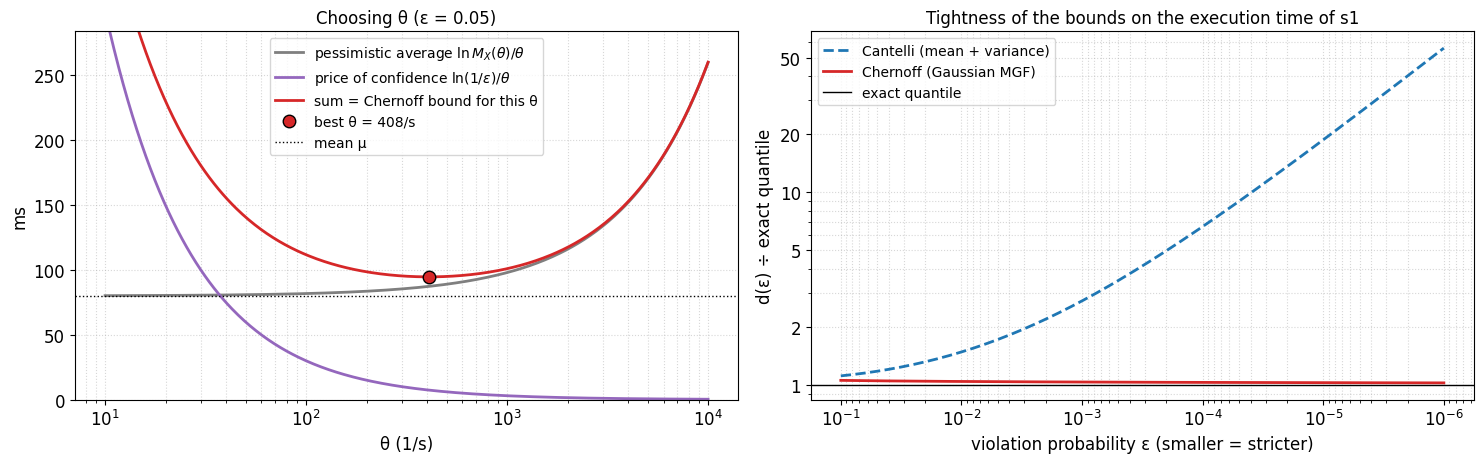

Tightness at ε = 0.05: Markov 17.8×, Cantelli 1.18×, Chernoff 1.05×.

In [14]:
fig, (ax_trade, ax_tight) = plt.subplots(1, 2, figsize=(15, 4.8))

theta_axis = np.logspace(1, 4, 400)
pessimistic = mu + 0.5 * theta_axis * sigma ** 2          # ln M_X(theta) / theta for a Gaussian
confidence_cost = np.log(1 / epsilon) / theta_axis
theta_best = np.sqrt(2 * np.log(1 / epsilon)) / sigma      # minimizer of the sum
d_best = mu + sigma * np.sqrt(2 * np.log(1 / epsilon))
ax_trade.semilogx(theta_axis, pessimistic * 1000, color="tab:gray", linewidth=2, label="pessimistic average $\\ln M_X(θ)/θ$")
ax_trade.semilogx(theta_axis, confidence_cost * 1000, color="tab:purple", linewidth=2, label="price of confidence $\\ln(1/ε)/θ$")
ax_trade.semilogx(theta_axis, (pessimistic + confidence_cost) * 1000, color="tab:red", linewidth=2, label="sum = Chernoff bound for this θ")
ax_trade.plot(theta_best, d_best * 1000, "o", color="tab:red", markersize=9, markeredgecolor="black", label=f"best θ = {theta_best:.0f}/s")
ax_trade.axhline(mu * 1000, color="black", linewidth=1, linestyle=":", label="mean μ")
ax_trade.set_ylim(0, 3 * d_best * 1000)
ax_trade.set_xlabel("θ (1/s)")
ax_trade.set_ylabel("ms")
ax_trade.set_title(f"Choosing θ (ε = {epsilon:g})", fontsize=12)
ax_trade.legend(fontsize=10)
ax_trade.grid(True, which="both", linestyle=":", alpha=0.5)

eps_axis = np.logspace(-1, -6, 200)
exact_axis = mu + norm.ppf(1 - eps_axis) * sigma
for label, bound, color, style in [("Cantelli (mean + variance)", mu + sigma * np.sqrt((1 - eps_axis) / eps_axis), "tab:blue", "--"),
                                   ("Chernoff (Gaussian MGF)", mu + sigma * np.sqrt(2 * np.log(1 / eps_axis)), "tab:red", "-")]:
    ax_tight.loglog(eps_axis, bound / exact_axis, style, color=color, linewidth=2, label=label)
ax_tight.axhline(1, color="black", linewidth=1, label="exact quantile")
ax_tight.invert_xaxis()
ax_tight.set_yticks([1, 2, 5, 10, 20, 50], labels=["1", "2", "5", "10", "20", "50"])
ax_tight.set_xlabel("violation probability ε (smaller = stricter)")
ax_tight.set_ylabel("d(ε) ÷ exact quantile")
ax_tight.set_title("Tightness of the bounds on the execution time of s1", fontsize=12)
ax_tight.legend(fontsize=10)
ax_tight.grid(True, which="both", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

exact = mu + norm.ppf(1 - epsilon) * sigma
display(Markdown(
    f"Tightness at ε = {epsilon:g}: Markov {mu / epsilon / exact:.1f}×, "
    f"Cantelli {(mu + sigma * np.sqrt((1 - epsilon) / epsilon)) / exact:.2f}×, Chernoff {d_best / exact:.2f}×."))

**What this shows.** Left: over $\theta$ (x-axis, log), the pessimistic average (gray) rises from $\mu$ while the
price of confidence (purple) falls. Their sum (red) is the Chernoff bound, and its minimum (dot) is the bound used.
Right: the tightness of each bound over $\varepsilon$ (stricter to the right, log scale); the black line at 1 is
the exact quantile. The Chernoff bound stays close to the exact quantile and gets relatively closer as $\varepsilon$
shrinks. Cantelli's bound puts a margin growing like $1/\sqrt{\varepsilon}$ on top of the mean and becomes useless
for strict targets.

**But for one Gaussian variable, Chernoff never beats the exact quantile $\mu + z\sigma$.** The MGF earns its place
only when random variables must be *combined* (a chain, a queue), where no quantile formula exists.

## 2. Why Not Just Add Quantiles?

The naive composition adds the per-service $(1-\varepsilon)$-quantiles. But per-service quantiles say nothing about
how services behave *together*. The sum of quantiles is exact if the services are perfectly dependent and too large
for independent Gaussians. It is **too small** when each service has rare slow items (probability $p$ below
$\varepsilon$): the chance of hitting at least one of them on a path, $1-(1-p)^K$, can exceed $\varepsilon$.

The cell builds that third case: $K$ independent services, each slow with probability `p_slow`. It compares the sum
of per-service p95s with the true p95 of the sum, and with two guaranteed compositions:

- **Union bound:** each service at its $(1-\varepsilon/K)$-quantile. The sum can only be exceeded if at least one
  service exceeds its share, so the total violation probability is at most $\varepsilon$, for *any* dependence.
  This is the PPG rule of `method_v2`.
- **Chernoff on the sum:** add the log-MGFs (property 1, needs independence) and convert back with Chernoff.

In [5]:
p_slow = 0.03                      # probability of a slow item at one service (cold start, GC pause); below epsilon
fast_mode = (0.050, 0.003)         # (mean, std) of a normal item's execution time (s)
slow_mode = (0.250, 0.020)         # (mean, std) of a slow item's execution time (s)
n_samples = 2_000_000
rng = np.random.default_rng(0)


def sample_mixture(rng, n):
    slow = rng.random(n) < p_slow
    return np.where(slow, rng.normal(*slow_mode, n), np.maximum(rng.normal(*fast_mode, n), 0.0))


def log_mgf_mixture():
    # ln[(1 - p) M_fast(theta) + p M_slow(theta)]: the MGF of a mixture is the mixture of the MGFs
    return np.logaddexp(np.log(1 - p_slow) + log_mgf_gauss(*fast_mode), np.log(p_slow) + log_mgf_gauss(*slow_mode))


rows = []
for K in [1, 2, 3]:
    parts = np.array([sample_mixture(rng, n_samples) for _ in range(K)])
    truth = np.quantile(parts.sum(axis=0), 1 - epsilon)
    sum_of_quantiles = sum(np.quantile(part, 1 - epsilon) for part in parts)
    union = sum(np.quantile(part, 1 - epsilon / K) for part in parts)
    chernoff_sum = np.min((K * log_mgf_mixture() - np.log(epsilon)) / theta_grid)
    rows.append(f"| {K} | {1 - (1 - p_slow) ** K:.3f} | {ms(truth)} | {ms(sum_of_quantiles)} ({sum_of_quantiles / truth:.2f}×) | "
                f"{ms(union)} ({union / truth:.2f}×) | {ms(chernoff_sum)} ({chernoff_sum / truth:.2f}×) |")
display(Markdown(
    f"p95 of the sum of K services, each slow with probability {p_slow:g}; ratio to the true p95 in brackets.\n\n"
    "| K | P(at least one slow item) | true p95 of the sum | sum of per-service p95s | union bound | Chernoff on the sum |\n"
    "|---|---|---|---|---|---|\n" + "\n".join(rows)))

K_long = 50   # a long path, to show the cost of splitting epsilon
display(Markdown(f"Cost of splitting ε over K = {K_long} services instead of 1 (per-service margin in units of σ): "
                 f"×{np.sqrt(2 * np.log(K_long / epsilon)) / np.sqrt(2 * np.log(1 / epsilon)):.2f} with Chernoff, "
                 f"×{np.sqrt((1 - epsilon / K_long) / (epsilon / K_long)) / np.sqrt((1 - epsilon) / epsilon):.2f} with Cantelli."))

p95 of the sum of K services, each slow with probability 0.03; ratio to the true p95 in brackets.

| K | P(at least one slow item) | true p95 of the sum | sum of per-service p95s | union bound | Chernoff on the sum |
|---|---|---|---|---|---|
| 1 | 0.030 | 56 ms | 56 ms (1.00×) | 56 ms (1.00×) | 241 ms (4.29×) |
| 2 | 0.059 | 280 ms | 112 ms (0.40×) | 461 ms (1.65×) | 350 ms (1.25×) |
| 3 | 0.087 | 347 ms | 168 ms (0.49×) | 742 ms (2.14×) | 441 ms (1.27×) |

Cost of splitting ε over K = 50 services instead of 1 (per-service margin in units of σ): ×1.52 with Chernoff, ×7.25 with Cantelli.

**What this shows.** Once $1-(1-p)^K$ exceeds $\varepsilon$ (second column), the true p95 jumps into the slow mode
and the sum of per-service p95s **under-covers** by a large factor. Both guaranteed compositions stay above the truth.
(Chernoff is loose for $K = 1$: the tail of one service is a cliff, which an exponential bound cannot follow.)

**The lesson:** one quantile per service is not enough to compose. The union bound needs each service's tail at a
stricter level $\varepsilon/K$; the MGF provides the tail at any level, and it composes by addition. With the MGF,
splitting $\varepsilon$ over $K$ services costs a margin of $\sqrt{2\ln(K/\varepsilon)}$, which grows very slowly
with $K$; with mean and variance alone (Cantelli) it grows like $\sqrt{K}$ (last line of the output).

## 3. The Queue: No Closed-Form Quantile, but an MGF Tail

With a queue, the latency is $W = Q + X$. Unrolling Lindley's recursion $Q_i = \max(0, Q_{i-1} + X_{i-1} - T_i)$
shows that the wait is the **maximum of a random walk**:
$Q = \max_{n \ge 0} \big(X_1 + \dots + X_n - (T_1 + \dots + T_n)\big)$, the work of the $n$ items before minus the
time the server had to do it.

Exact queueing theory gives, for Poisson arrivals, the mean (Pollaczek–Khinchine), higher moments (Takács), and
the distribution only as a transform that must be inverted numerically; for general arrivals, not even the mean.
There is no p95 formula. The *tail*, however, is known (Cramér–Lundberg): $P(Q > q) \approx C\,e^{-\theta^* q}$,
where $\theta^* > 0$ solves $\rho(\theta^*) = 1$. The decay rate of a queue's tail is set by the MGFs.

The plot shows the simulated tail $P(Q > q)$ on a log scale (straight line = exponential decay) and a line with
slope $-\theta^*$ computed from the MGFs alone.

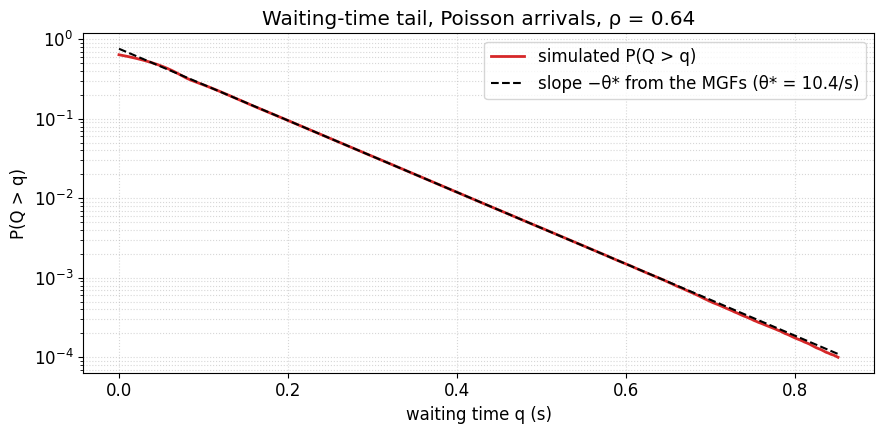

Share of items that wait: 64.0% (theory for Poisson: ρ = 64%). Decay rate of the simulated tail: 10.5/s; θ* from the MGFs: 10.4/s.

In [6]:
latency_poisson, wait_poisson = simulate("poisson", arrival_rate, [gauss_sampler(mu, sigma)], 4000, 2500,
                                         np.random.default_rng(1), warmup=500)
latency_poisson, wait_poisson = latency_poisson.ravel(), wait_poisson.ravel()

log_rho_poisson = log_mgf_gauss(mu, sigma) + log_gap_mgf("poisson", arrival_rate)
theta_star = theta_grid[np.argmax((theta_grid > 1) & (log_rho_poisson >= 0))]

q_axis = np.linspace(0, np.quantile(wait_poisson, 1 - 1e-4), 300)
ccdf = 1 - np.searchsorted(np.sort(wait_poisson), q_axis, side="right") / wait_poisson.size
fit_range = (ccdf < 1e-1) & (ccdf > 1e-4)      # the tail region, away from the atom at zero and the noisy end
fitted_slope = -np.polyfit(q_axis[fit_range], np.log(ccdf[fit_range]), 1)[0]
anchor = np.argmax(fit_range)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.semilogy(q_axis, np.where(ccdf > 0, ccdf, np.nan), color="tab:red", linewidth=2, label="simulated P(Q > q)")
ax.semilogy(q_axis, ccdf[anchor] * np.exp(-theta_star * (q_axis - q_axis[anchor])), "k--", linewidth=1.5,
            label=f"slope −θ* from the MGFs (θ* = {theta_star:.1f}/s)")
ax.set_xlabel("waiting time q (s)")
ax.set_ylabel("P(Q > q)")
ax.set_title(f"Waiting-time tail, Poisson arrivals, ρ = {arrival_rate * mu:.2f}")
ax.legend()
ax.grid(True, which="both", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

display(Markdown(f"Share of items that wait: {np.mean(wait_poisson > 0):.1%} (theory for Poisson: ρ = {arrival_rate * mu:.0%}). "
                 f"Decay rate of the simulated tail: {fitted_slope:.1f}/s; θ* from the MGFs: {theta_star:.1f}/s."))

**What this shows.** The simulated tail is a straight line whose slope matches $\theta^*$, computed without any
simulation. The MGF gives the *slope*; only the starting level $C$ has no closed form. Every MGF-based latency bound
therefore has the right shape and differs from the truth only in its level: it replaces $C$ by something computable
and at least as large. How much larger decides the tightness, and that is where the methods below differ.

## 4. Five Ways to Bound the Latency of One Service

| | method | idea | guarantee? |
|---|---|---|---|
| A | execution-time quantile | $\mu + z_{1-\varepsilon}\sigma$, what the GP gives directly; ignores waiting | no |
| B | Gaussian approximation | exact mean and variance of $W$ (Pollaczek–Khinchine, Takács; Poisson only), then $\mathbb{E}[W] + z_{1-\varepsilon}\sqrt{\mathrm{Var}[W]}$ | no |
| C | Monte Carlo + order statistic | simulate $n$ independent latencies from the model; take the $k$-th smallest, with $k$ chosen from the Binomial$(n, 1-\varepsilon)$ distribution so that it is above the true quantile with probability $\ge 1-\delta$ | yes, given the model; needs $n \ge \ln\delta/\ln(1-\varepsilon)$ |
| D | SNC bound (`method_v2`) | union bound over queue lengths $n$, Chernoff per term, geometric series | yes |
| E | martingale bound (Kingman) | same MGFs, but a maximal inequality instead of the sum over $n$ | yes |

The two MGF bounds:

$$\text{D: } d(\varepsilon) = \min_{\theta:\ \rho(\theta) < 1} \frac{\ln M_X(\theta) - \ln(1-\rho(\theta)) - \ln\varepsilon}{\theta}, \qquad
\text{E: } d(\varepsilon) = \min_{\theta:\ \rho(\theta) \le 1} \frac{\ln M_X(\theta) - \ln\varepsilon}{\theta}.$$

**Why E holds.** For $\rho(\theta) \le 1$, the exponential $e^{\theta \cdot (\text{random walk after } n \text{ steps})}$
has expectation $\rho(\theta)^n \le 1$ and does not grow in expectation from step to step (a supermartingale).
Ville's maximal inequality bounds the chance that such a process *ever* exceeds $e^{\theta q}$ by $e^{-\theta q}$,
the price of a single Markov step rather than a sum over $n$. So $P(Q > q) \le e^{-\theta q}$. The item's own $X$ is
independent of its wait, which gives $P(W > d) \le \mathbb{E}[e^{-\theta(d - X)}] = M_X(\theta)\,e^{-\theta d}$.

**D vs E:** E drops the queue term $-\ln(1-\rho(\theta))/\theta$ and may use $\theta$ up to $\theta^*$. D pays for
summing over all queue lengths and must stay strictly below $\theta^*$. Both hold for any renewal arrival process
and compose with the union bound in the same way.

The ground truth is a long simulation. Monte Carlo is repeated `n_reps` times to show how often it misses.

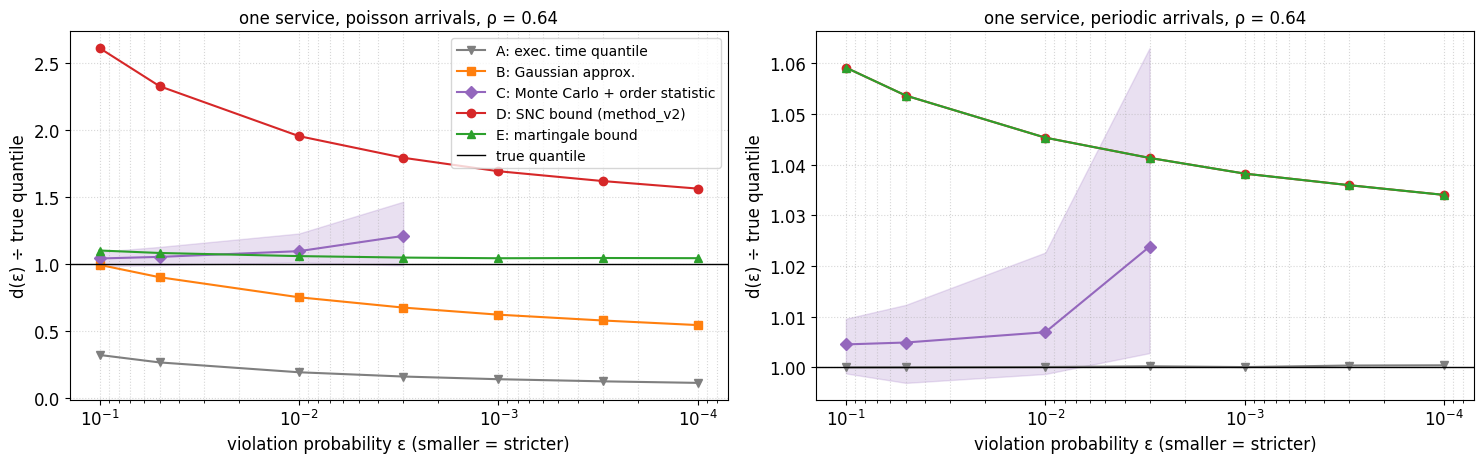

Monte Carlo (n = 2000, Poisson): share of repetitions below the truth (target ≤ δ = 0.05): ε = 0.1: 7%, ε = 0.05: 3%, ε = 0.01: 0%, ε = 0.003: 3%, ε = 0.001: 0%, ε = 0.0003: 0%, ε = 0.0001: 0%. No bound exists below ε ≈ 1.5e-03.

In [7]:
def exec_quantile(m, s, eps):
    return m + norm.ppf(1 - eps) * s


def gauss_approx_mg1(m, s, rate, eps):
    # exact mean and variance of the M/G/1 latency (Pollaczek-Khinchine, Takacs), then a Gaussian quantile
    rho = rate * m
    if rho >= 1:
        return np.inf
    ex2, ex3 = m ** 2 + s ** 2, m ** 3 + 3 * m * s ** 2       # moments of a Gaussian execution time
    mean_wait = rate * ex2 / (2 * (1 - rho))
    second_wait = 2 * mean_wait ** 2 + rate * ex3 / (3 * (1 - rho))
    return m + mean_wait + norm.ppf(1 - eps) * np.sqrt(second_wait - mean_wait ** 2 + s ** 2)


def order_statistic_bound(samples, eps, delta=delta_mc):
    # k-th smallest sample, with k the smallest index such that P(Binomial(n, 1 - eps) <= k - 1) >= 1 - delta
    n = samples.shape[-1]
    k = np.arange(1, n + 1)
    valid = binom.cdf(k - 1, n, 1 - eps) >= 1 - delta
    if not valid.any():
        return np.full(samples.shape[:-1], np.nan)     # too few samples for any bound at this eps
    return np.sort(samples, axis=-1)[..., k[valid][0] - 1]


def monte_carlo_samples(process, rate, samplers, n_reps, rng, warmup=300):
    # n_reps x n_mc independent latency samples: one sample (the last item) per independent run after the warm-up
    latency, _ = simulate(process, rate, samplers, n_reps * n_mc, warmup + 1, rng, warmup)
    return latency[:, 0].reshape(n_reps, n_mc)


method_style = {   # one fixed color and marker per method, reused in every figure
    "A: exec. time quantile": ("tab:gray", "v"),
    "B: Gaussian approx.": ("tab:orange", "s"),
    "C: Monte Carlo + order statistic": ("tab:purple", "D"),
    "D: SNC bound (method_v2)": ("tab:red", "o"),
    "E: martingale bound": ("tab:green", "^"),
}
n_reps = 30
truth_samples = {"poisson": latency_poisson,
                 "periodic": simulate("periodic", arrival_rate, [gauss_sampler(mu, sigma)], 4000, 2500,
                                      np.random.default_rng(1), warmup=500)[0].ravel()}

single = {}   # single[process][method] = d(eps) over `epsilons`; Monte Carlo: (n_reps, len(epsilons))
for process in processes:
    log_mx, log_gap = log_mgf_gauss(mu, sigma), log_gap_mgf(process, arrival_rate)
    mc = monte_carlo_samples(process, arrival_rate, [gauss_sampler(mu, sigma)], n_reps, np.random.default_rng(9))
    single[process] = {
        "truth": np.quantile(truth_samples[process], 1 - epsilons),
        "A: exec. time quantile": exec_quantile(mu, sigma, epsilons),
        "B: Gaussian approx.": (np.array([gauss_approx_mg1(mu, sigma, arrival_rate, e) for e in epsilons])
                                if process == "poisson" else None),
        "C: Monte Carlo + order statistic": np.stack([order_statistic_bound(mc, e) for e in epsilons], axis=1),
        "D: SNC bound (method_v2)": np.array([snc_bound(log_mx, log_gap, e) for e in epsilons]),
        "E: martingale bound": np.array([martingale_bound(log_mx, log_gap, e) for e in epsilons]),
    }

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
for ax, process in zip(axes, processes):
    plot_ratios(ax, single[process], method_style, f"one service, {process} arrivals, ρ = {arrival_rate * mu:.2f}")
axes[0].legend(fontsize=10)
plt.tight_layout()
plt.show()

mc_poisson = single["poisson"]["C: Monte Carlo + order statistic"]
mc_below = np.nanmean(mc_poisson < single["poisson"]["truth"], axis=0)
display(Markdown(f"Monte Carlo (n = {n_mc}, Poisson): share of repetitions below the truth (target ≤ δ = {delta_mc:g}): "
                 + ", ".join(f"ε = {e:g}: {s:.0%}" for e, s in zip(epsilons, mc_below) if not np.isnan(s))
                 + f". No bound exists below ε ≈ {1 - delta_mc ** (1 / n_mc):.1e}."))

**What this shows.** Each panel shows $d(\varepsilon)$ ÷ the true quantile over $\varepsilon$ (stricter to the
right); below the black line means under-coverage. Monte Carlo is the median over repetitions, with a min–max band.

- **Poisson (left):** A is far below the truth: it is not a latency bound. B looks plausible at loose $\varepsilon$
  but under-covers more and more as $\varepsilon$ shrinks, because the latency (most items don't wait, exponential
  tail) is not Gaussian. C is tight and misses about as often as $\delta$ allows, but it stops where `n_mc` samples
  are too few. D covers but is loose by a large factor. **E covers and sits just above the truth at every
  $\varepsilon$.**
- **Periodic (right):** nobody waits, so A is exact, and D and E coincide with the Gaussian Chernoff bound of
  Section 1, a few percent above the truth.

**The looseness of `method_v2` under Poisson arrivals is not a limitation of MGFs.** E uses the same two MGFs and is
nearly tight; D's extra slack comes from summing over all queue lengths.

### 4b. Dependence on the Load

The same comparison for Poisson arrivals over utilizations $\rho$, at two violation probabilities. The truth is
re-simulated for each load with a longer warm-up, since queues near saturation settle slowly.

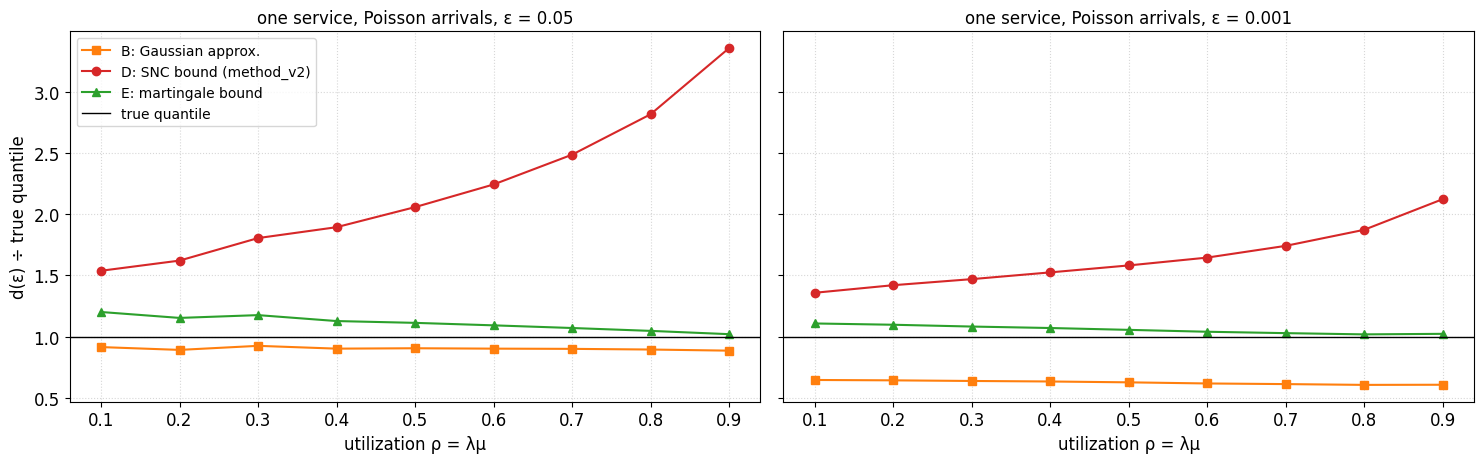

In [8]:
utilizations = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])
load_eps = [epsilon, 1e-3]
load_methods = ["B: Gaussian approx.", "D: SNC bound (method_v2)", "E: martingale bound"]
load_ratios = {eps: {name: [] for name in load_methods} for eps in load_eps}
for rho in utilizations:
    rate = rho / mu
    samples = simulate("poisson", rate, [gauss_sampler(mu, sigma)], 2000, 6000, np.random.default_rng(5), warmup=2000)[0].ravel()
    log_mx, log_gap_load = log_mgf_gauss(mu, sigma), log_gap_mgf("poisson", rate)
    for eps in load_eps:
        truth = np.quantile(samples, 1 - eps)
        load_ratios[eps]["B: Gaussian approx."].append(gauss_approx_mg1(mu, sigma, rate, eps) / truth)
        load_ratios[eps]["D: SNC bound (method_v2)"].append(snc_bound(log_mx, log_gap_load, eps) / truth)
        load_ratios[eps]["E: martingale bound"].append(martingale_bound(log_mx, log_gap_load, eps) / truth)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), sharey=True)
for ax, eps in zip(axes, load_eps):
    for name, ratios in load_ratios[eps].items():
        color, marker = method_style[name]
        ax.plot(utilizations, ratios, marker=marker, color=color, linewidth=1.5, label=name)
    ax.axhline(1, color="black", linewidth=1, label="true quantile")
    ax.set_xlabel("utilization ρ = λμ")
    ax.set_title(f"one service, Poisson arrivals, ε = {eps:g}", fontsize=12)
    ax.grid(True, linestyle=":", alpha=0.5)
axes[0].set_ylabel("d(ε) ÷ true quantile")
axes[0].legend(fontsize=10)
plt.tight_layout()
plt.show()

**What this shows.** Over the utilization (x-axis):

- **D (SNC)** gets looser as the load grows: $\theta^*$ falls towards zero, and the queue term
  $-\ln(1-\rho(\theta))/\theta$ must be paid at a $\theta$ strictly below it.
- **E (martingale)** stays close to 1 everywhere and gets tighter with load; its slack is largest at low load.
- **B (Gaussian)** under-covers at every load, and much more at the stricter $\varepsilon$.

## 5. A Chain of Services

Three services s1 → s2 → s3 (parameters printed below the plot; s1 and s2 as in `why_poisson_is_loose`), Poisson
arrivals into s1, each later service fed by the departures of the one before. Execution times are independent across
services; the union bound would hold for any dependence. Compared:

- **A:** sum of per-service execution-time quantiles at $\varepsilon$.
- **SNC, no split:** per-service SNC bounds at $\varepsilon$, added (no guarantee: the budget is used $K$ times).
- **PPG with SNC / with martingale:** per-service bounds at $\varepsilon/K$, added (the PPG rule, two node bounds).
- **C:** Monte Carlo of the whole chain with the order-statistic bound.

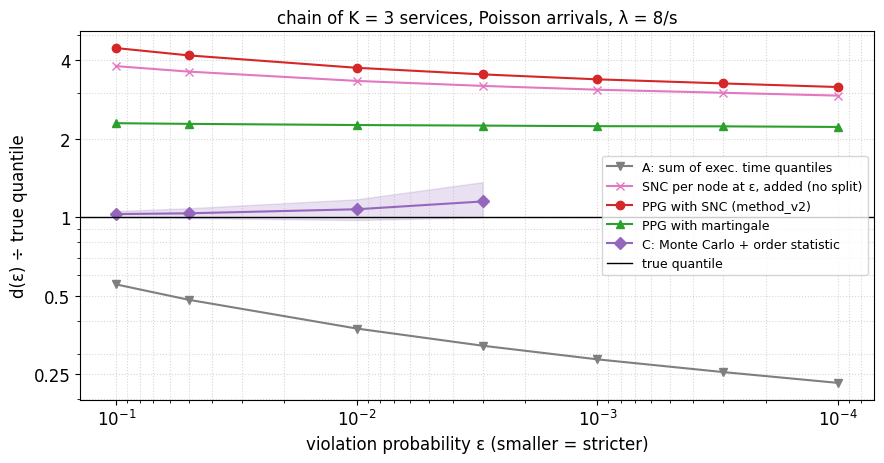

Nodes (mean, std): s1 = (80 ms, 6 ms), s2 = (72 ms, 1 ms), s3 = (60 ms, 4 ms)

In [9]:
chain_nodes = [(0.080, 0.006), (0.072, 0.001), (0.060, 0.0035)]   # (mean, std) of s1, s2, s3 (s)
K = len(chain_nodes)
chain_samplers = [gauss_sampler(*node) for node in chain_nodes]
chain_truth = simulate("poisson", arrival_rate, chain_samplers, 4000, 2500, np.random.default_rng(2), warmup=500)[0].ravel()
chain_mc = monte_carlo_samples("poisson", arrival_rate, chain_samplers, n_reps, np.random.default_rng(12))
log_gap_chain = log_gap_mgf("poisson", arrival_rate)

chain_style = {
    "A: sum of exec. time quantiles": ("tab:gray", "v"),
    "SNC per node at ε, added (no split)": ("tab:pink", "x"),
    "PPG with SNC (method_v2)": ("tab:red", "o"),
    "PPG with martingale": ("tab:green", "^"),
    "C: Monte Carlo + order statistic": ("tab:purple", "D"),
}


def added_node_bounds(bound, level):
    return np.array([sum(bound(log_mgf_gauss(m, s), log_gap_chain, level(e)) for m, s in chain_nodes) for e in epsilons])


chain = {
    "truth": np.quantile(chain_truth, 1 - epsilons),
    "A: sum of exec. time quantiles": sum(exec_quantile(m, s, epsilons) for m, s in chain_nodes),
    "SNC per node at ε, added (no split)": added_node_bounds(snc_bound, lambda e: e),
    "PPG with SNC (method_v2)": added_node_bounds(snc_bound, lambda e: e / K),
    "PPG with martingale": added_node_bounds(martingale_bound, lambda e: e / K),
    "C: Monte Carlo + order statistic": np.stack([order_statistic_bound(chain_mc, e) for e in epsilons], axis=1),
}

fig, ax = plt.subplots(figsize=(9, 4.8))
plot_ratios(ax, chain, chain_style, f"chain of K = {K} services, Poisson arrivals, λ = {arrival_rate:g}/s")
ax.set_yscale("log")
ax.set_yticks([0.25, 0.5, 1, 2, 4], labels=["0.25", "0.5", "1", "2", "4"])
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
display(Markdown("Nodes (mean, std): " + ", ".join(f"s{k + 1} = ({ms(m)}, {ms(s)})" for k, (m, s) in enumerate(chain_nodes))))

**What this shows** (log y-axis)**.**
- **A** is far below the truth.
- Both **PPG** variants cover everywhere; the martingale one is much tighter, since the advantage of Section 4 is
  paid out at every node. Adding SNC bounds *without* splitting $\varepsilon$ (pink) is barely tighter than the PPG:
  the union bound's price is small, and the slack sits in the node bounds.
- Even the martingale PPG is looser here than for one service: every node bound assumes Poisson arrivals, but s2 and
  s3 receive the smoothed departures of s1 (`why_poisson_is_loose`, Section 8). That is a modeling choice in the
  composition, not a property of MGFs.
- **Monte Carlo** simulates the real chain, sees the smoothing, and is the tightest wherever it exists.

## 6. Cost: Why a Closed Form Matters

Monte Carlo was the tightest guaranteed method, but the optimizer evaluates the bound for every candidate
configuration. The cell measures the time per configuration on the chain of Section 5, and how many samples Monte
Carlo needs before any bound exists.

In [10]:
n_configs = 200
config_means = np.random.default_rng(3).uniform(0.6, 1.4, (n_configs, K)) * np.array([m for m, _ in chain_nodes])

start = time.perf_counter()
log_gap_row = log_gap_mgf("poisson", arrival_rate)[None, :]
bounds = 0.0
for k, (_, s) in enumerate(chain_nodes):
    # the martingale bound for all configurations at once: one row per configuration, one column per theta
    log_mx = theta_grid[None, :] * config_means[:, [k]] + 0.5 * theta_grid[None, :] ** 2 * s ** 2
    values = np.where(log_mx + log_gap_row <= 0, (log_mx - np.log(epsilon / K)) / theta_grid[None, :], np.inf)
    bounds = bounds + values.min(axis=1)
time_bound = (time.perf_counter() - start) / n_configs

n_timed = 10     # Monte Carlo is slow; time a few configurations and report the time per configuration
start = time.perf_counter()
for c in range(n_timed):
    samplers = [gauss_sampler(config_means[c, k], s) for k, (_, s) in enumerate(chain_nodes)]
    order_statistic_bound(monte_carlo_samples("poisson", arrival_rate, samplers, 1, np.random.default_rng(c))[0], epsilon)
time_mc = (time.perf_counter() - start) / n_timed

n_needed = np.ceil(np.log(delta_mc) / np.log(1 - epsilons))
display(Markdown(
    f"Time per configuration: MGF bound {time_bound * 1e3:.3f} ms, Monte Carlo (n = {n_mc}) {time_mc * 1e3:.1f} ms "
    f"(≈ {time_mc / time_bound:.0f}× slower).\n\n| ε | smallest n for any bound | Monte Carlo time at that n |\n|---|---|---|\n"
    + "\n".join(f"| {e:g} | {n:.0f} | {time_mc * n / n_mc * 1e3:.1f} ms |" for e, n in zip(epsilons, n_needed))))

Time per configuration: MGF bound 0.339 ms, Monte Carlo (n = 2000) 121.7 ms (≈ 359× slower).

| ε | smallest n for any bound | Monte Carlo time at that n |
|---|---|---|
| 0.1 | 29 | 1.8 ms |
| 0.05 | 59 | 3.6 ms |
| 0.01 | 299 | 18.2 ms |
| 0.003 | 998 | 60.7 ms |
| 0.001 | 2995 | 182.3 ms |
| 0.0003 | 9985 | 607.7 ms |
| 0.0001 | 29956 | 1823.1 ms |

**What this shows.** The MGF bound costs a few vectorized array operations per configuration, independent of
$\varepsilon$. Monte Carlo is hundreds of times slower (ratio printed; machine-dependent), and its sample count grows
like $1/\varepsilon$; the smallest $n$ in the table only makes a bound *exist*, a tight one needs several times more.
The closed form is also smooth in the configuration (no sampling noise for the optimizer) and decomposes into
interpretable terms.

## 7. When the Gaussian MGF Is Wrong

Every MGF bound is only as good as its MGF. Here the execution time of one service is the mixture of Section 2
(rare slow items), at a low arrival rate `low_rate` so that execution time, not queueing, dominates the latency.
The bounds are computed from the **Gaussian MGF** with the mixture's mean and variance (what a GP with a Gaussian
likelihood reports) and from the **true mixture MGF**.

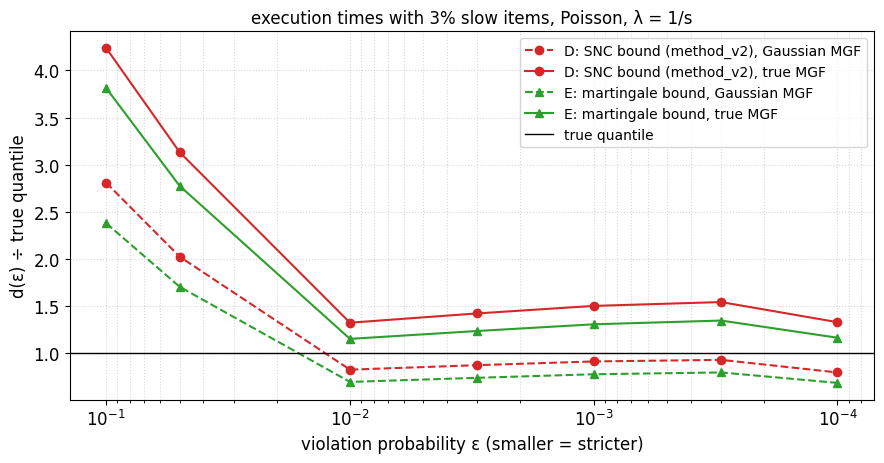

In [11]:
low_rate = 1.0    # items/s, so that the queue matters little
mix_mean = (1 - p_slow) * fast_mode[0] + p_slow * slow_mode[0]
mix_var = ((1 - p_slow) * (fast_mode[1] ** 2 + fast_mode[0] ** 2) + p_slow * (slow_mode[1] ** 2 + slow_mode[0] ** 2)) - mix_mean ** 2
mix_truth = np.quantile(simulate("poisson", low_rate, [sample_mixture], 4000, 2500, np.random.default_rng(3), warmup=500)[0].ravel(),
                        1 - epsilons)
log_gap_low = log_gap_mgf("poisson", low_rate)
log_mx_by_mgf = {"Gaussian MGF": log_mgf_gauss(mix_mean, np.sqrt(mix_var)), "true MGF": log_mgf_mixture()}
misspecified = {(method, mgf): np.array([bound(log_mx, log_gap_low, e) for e in epsilons])
                for method, bound in [("D: SNC bound (method_v2)", snc_bound), ("E: martingale bound", martingale_bound)]
                for mgf, log_mx in log_mx_by_mgf.items()}

fig, ax = plt.subplots(figsize=(9, 4.8))
for (method, mgf), values in misspecified.items():
    ax.semilogx(epsilons, values / mix_truth, "--" if mgf == "Gaussian MGF" else "-", marker=method_style[method][1],
                color=method_style[method][0], linewidth=1.5, label=f"{method}, {mgf}")
ax.axhline(1, color="black", linewidth=1, label="true quantile")
ax.invert_xaxis()
ax.set_xlabel("violation probability ε (smaller = stricter)")
ax.set_ylabel("d(ε) ÷ true quantile")
ax.set_title(f"execution times with {p_slow:.0%} slow items, Poisson, λ = {low_rate:g}/s", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, which="both", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

**What this shows.** With the true MGF (solid), both bounds cover everywhere. With the Gaussian MGF (dashed), they
cover only while $\varepsilon$ is above `p_slow`; below it the true quantile jumps into the slow mode and both
bounds fall under it. The guarantee is exact *relative to the MGF*, and a Gaussian likelihood silently assumes a
light, symmetric tail. Heavy tails are worse still: no MGF exists (Section 0). Before relying on a Gaussian MGF, check
the upper tail of each service's residuals (e.g. a QQ plot, or the empirical p99 against $\mu + z_{0.99}\sigma$).

## 8. Verdict

Computed from the results above: $d(\varepsilon)$ ÷ the true quantile, ✗ = below 0.99 (under-covers; within 1% of 1
is simulation noise), n/a = too few Monte Carlo samples.

In [12]:
def pick(results, name, eps):
    values = results.get(name)
    if values is None:
        return None
    i = int(np.argmin(np.abs(np.log(epsilons) - np.log(eps))))
    value = np.nanmedian(values[:, i]) if values.ndim == 2 else values[i]
    return value / results["truth"][i]


def cell(ratio):
    if ratio is None:
        return "–"
    if np.isnan(ratio):
        return "n/a"
    return f"{ratio:.2f}×" + (" ✗" if ratio < 0.99 else "")   # 0.99: ratios within 1% of 1 are simulation noise


scenarios = []
for process in processes:
    for eps in [epsilon, 1e-3]:
        scenarios.append((f"one service, {process}, ε = {eps:g}", [pick(single[process], name, eps) for name in method_style]))
for eps in [epsilon, 1e-3]:
    scenarios.append((f"chain K = {K}, Poisson, ε = {eps:g} (D, E as PPG)",
                      [pick(chain, "A: sum of exec. time quantiles", eps), None, pick(chain, "C: Monte Carlo + order statistic", eps),
                       pick(chain, "PPG with SNC (method_v2)", eps), pick(chain, "PPG with martingale", eps)]))
mix = {"truth": mix_truth, **{f"{m} | {g}": v for (m, g), v in misspecified.items()}}
for mgf in log_mx_by_mgf:
    scenarios.append((f"slow items, {mgf}, ε = 0.001",
                      [None, None, None, pick(mix, f"D: SNC bound (method_v2) | {mgf}", 1e-3), pick(mix, f"E: martingale bound | {mgf}", 1e-3)]))

display(Markdown("| scenario | " + " | ".join(method_style) + " |\n|---|" + "---|" * len(method_style) + "\n"
                 + "\n".join(f"| {name} | " + " | ".join(cell(r) for r in ratios) + " |" for name, ratios in scenarios)
                 + f"\n\nCost per configuration: MGF bound {time_bound * 1e3:.3f} ms, Monte Carlo {time_mc * 1e3:.1f} ms (n = {n_mc})."))

| scenario | A: exec. time quantile | B: Gaussian approx. | C: Monte Carlo + order statistic | D: SNC bound (method_v2) | E: martingale bound |
|---|---|---|---|---|---|
| one service, poisson, ε = 0.05 | 0.26× ✗ | 0.90× ✗ | 1.05× | 2.32× | 1.08× |
| one service, poisson, ε = 0.001 | 0.14× ✗ | 0.62× ✗ | n/a | 1.69× | 1.04× |
| one service, periodic, ε = 0.05 | 1.00× | – | 1.00× | 1.05× | 1.05× |
| one service, periodic, ε = 0.001 | 1.00× | – | n/a | 1.04× | 1.04× |
| chain K = 3, Poisson, ε = 0.05 (D, E as PPG) | 0.48× ✗ | – | 1.04× | 4.18× | 2.28× |
| chain K = 3, Poisson, ε = 0.001 (D, E as PPG) | 0.28× ✗ | – | n/a | 3.38× | 2.24× |
| slow items, Gaussian MGF, ε = 0.001 | – | – | – | 0.91× ✗ | 0.78× ✗ |
| slow items, true MGF, ε = 0.001 | – | – | – | 1.50× | 1.31× |

Cost per configuration: MGF bound 0.339 ms, Monte Carlo 121.7 ms (n = 2000).

**Why not naively?** Adding GP quantiles ignores the queue (A) and can under-cover even without one, because
quantiles don't add (Section 2). Matching the queue's exact mean and variance to a Gaussian (B) under-covers for
strict targets. A plain Monte Carlo quantile is an estimate, below the truth half of the time.

| the MGF / Chernoff route is a good choice when … | … and not when |
|---|---|
| there is a queue: the MGF governs its tail (Section 3) | there is one service and no queue: the exact quantile is better (Section 1) |
| paths are composed: log-MGFs add, splitting ε costs little (Section 2) | the target is moderate (p95), configurations are few, and compute is available: Monte Carlo is tighter, especially in chains (Section 5) |
| targets are strict or evaluations are many: cost independent of ε, far cheaper than simulation (Section 6) | execution times have heavy or multi-modal tails: a Gaussian MGF under-covers, a heavy tail has none (Section 7) |

**For `method_v2`:**
1. Keep the MGF framework, but **replace the SNC node bound by the martingale bound**: same inputs, same cost, same
   PPG composition, much tighter under Poisson arrivals. This changes every reported bound, so coverage must be
   re-checked there.
2. The remaining slack along a chain comes from assuming the external arrival process at every node; that is a
   separate, composition-level issue.
3. Check execution-time tails before trusting the Gaussian MGF, and use Monte Carlo as the reference in the
   evaluation.